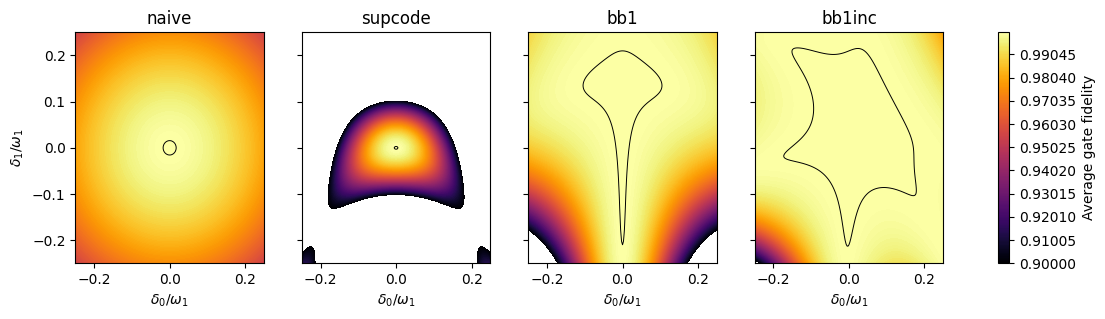

In [16]:
import numpy as np
import qutip as qt
from qutip.core.metrics import fidelity
from qutip_qip.operations import rx
import matplotlib.pyplot as plt

##############################################################################
# 0.  Qubit operators & helpers
##############################################################################
sig_x, sig_y, sig_z = qt.sigmax(), qt.sigmay(), qt.sigmaz()
d = 2                                              # Hilbert-space dimension

def avg_gate_fidelity(U, U_target):
    """Hammond–Nielsen average gate fidelity for a single qubit."""
    return (abs((U_target.dag() * U).tr())**2 + d) / (d * (d + 1))

def segment_propagator(delta0, delta1, w1, theta, phi, is_gap):
    """
    One rectangular segment → U = exp(−i H dt)
      delta0, delta1 : fractional detuning / amplitude errors (−0.25…0.25)
      w1             : nominal Rabi frequency (rad s⁻¹)
      theta          : *design* rotation angle of the segment (rad)
      phi            : microwave phase (rad)
      is_gap         : True ⇒ microwave OFF
    NOTE:  dt is **not** corrected for δ₁.  Amplitude errors therefore
           change the actual rotation angle, matching the paper’s model.
    """
    if is_gap:                                    # microwave OFF
        H  = delta0 * w1 * sig_z / 2
        dt = abs(theta) / w1                      # treat θ as an “area”
    else:                                         # driven segment
        H  = delta0 * w1 * sig_z / 2 \
           + (1 + delta1) * w1 / 2 * (
                 np.cos(phi) * sig_x + np.sin(phi) * sig_y)
        dt = abs(theta) / w1                      # FIXED length, no δ₁
    return (-1j * H * dt).expm()

##############################################################################
# 1.  Composite-pulse builders
##############################################################################
def naive(theta=np.pi / 2):
    return [(theta, 0.0, False)]

def supcode(theta_target=np.pi / 2):
    # Barnes–Cywiński 5-piece SUPCODE (Phys. Rev. A 89 022310) → π/2 gate
    theta = 2.5 * np.pi
    τ1    = 5  * np.pi / 4
    τ3    = 15 * np.pi / 4
    return [
        (τ1,       0.0, True),
        (theta/2,  0.0, False),
        (τ3,       0.0, True),
        (theta/2,  0.0, False),
        (τ1,       0.0, True),
    ]

def bb1(theta=np.pi / 2):
    φ = np.arccos(-theta / (4 * np.pi))
    return [
        (theta/2, 0.0, False),
        (np.pi,   φ,   False),
        (2*np.pi, 3*φ, False),
        (np.pi,   φ,   False),
        (theta/2, 0.0, False),
    ]

def bb1inc(theta=np.pi / 2):
    φ  = np.arccos(-theta / (4 * np.pi))
    θ1 = theta/2 - np.arcsin(np.sin(theta/2) / 2)
    θ2 = 2*np.pi - 2*np.arcsin(np.sin(theta/2) / 2)
    θ3 = 2*np.pi - np.arcsin(np.sin(theta/2) / 2)
    return [
        (theta/2, 0.0, False),
        (np.pi,   φ,   False),
        (2*np.pi, 3*φ, False),
        (np.pi,   φ,   False),
        (θ3,      0.0, False),
        (θ2,      np.pi, False),
        (θ1,      0.0, False),
    ]

pulse_dict = {
    "naive":   naive,
    "supcode": supcode,
    "bb1":     bb1,
    "bb1inc":  bb1inc,
}

##############################################################################
# 2.  Sweep (δ₀, δ₁) and compute fidelities
##############################################################################
w1   = 2 * np.pi * 1.0e6                     # 1 MHz Rabi
grid = np.linspace(-0.25, 0.25, 201)         # finer 201×201 grid
δ0g, δ1g = np.meshgrid(grid, grid)
F_dict = {name: np.zeros_like(δ0g) for name in pulse_dict}

U_target = rx(np.pi / 2)                     # ideal X/2 gate

for name, builder in pulse_dict.items():
    pulse = builder()
    for i, d0 in enumerate(grid):
        for j, d1 in enumerate(grid):
            U = qt.qeye(2)
            for θ, φ, gap in pulse:
                U = segment_propagator(d0, d1, w1, θ, φ, gap) * U
            F_dict[name][j, i] = avg_gate_fidelity(U, U_target)

##############################################################################
# 3.  Plot  (contourf; imshow fallback for any flat surface)
##############################################################################
fig, axs = plt.subplots(1, 4, figsize=(14, 3.0), sharey=True)

for ax, (name, F) in zip(axs, F_dict.items()):

    if np.allclose(F.max(), F.min()):
        cs = ax.imshow(
            F,
            extent=(grid.min(), grid.max(), grid.min(), grid.max()),
            origin='lower', cmap='inferno',
            vmin=F.min() - 1e-4, vmax=F.max() + 1e-4,
            aspect='auto'
        )
    else:
        cs = ax.contourf(δ0g, δ1g, F, levels=np.linspace(0.9, 1.0, 200),
                         cmap='inferno')

    if F.max() >= 0.9999 >= F.min():
        ax.contour(δ0g, δ1g, F, levels=[0.9999],
                   colors='k', linewidths=0.7)

    ax.set_title(name)
    ax.set_xlabel(r'$\delta_0 / \omega_1$')

axs[0].set_ylabel(r'$\delta_1 / \omega_1$')
plt.colorbar(cs, ax=axs, location='right', label='Average gate fidelity')
plt.show()
